# DANN Feature Evaluation

## Objective
Compare DANN-extracted features against manually extracted features on the same
two tasks: site classification (should be low) and pathology classification (should be high).

## Experiment Design
- **DANN features:** 288 features from Domain Adversarial Neural Network
- **Manual features:** Standard EEG features (power, coherence, covariance)
- **Site classification:** 5-fold stratified CV, MCC metric
- **Pathology classification:** LOSO CV with k=30 calibration, AUC metric
- **Model:** CatBoost (same hyperparameters as manual feature experiments)
- **Harmonization:** raw only (DANN is designed to not need harmonization)

## Note on interpretation
DANN was explicitly trained to remove site signal and preserve pathology signal.
Strong performance on these metrics is expected. The key question is: **how does it compare
quantitatively** to the manual features + harmonization approach?

In [1]:
import os
from pathlib import Path

if Path.cwd().name != 'eeg-site-effects':
    os.chdir('../..')
print('Working directory:', Path.cwd())

Working directory: /dmj/fizmed/kchorzela/licencjat/eeg-site-effects


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# DANN results
DANN_SITE_FILE  = 'results/tables/04_dann/site_clf_results.csv'
DANN_PATHO_FILE = 'results/tables/04_dann/patho_clf_results.csv'

# Manual baseline results (for comparison)
MANUAL_SITE_FILE  = 'results/tables/02_site_effect/site_clf_results.csv'
MANUAL_PATHO_FILE = 'results/tables/03_harmonization/patho_clf_results.csv'

FIGURES_DIR = 'results/figures/04_dann'
TABLES_DIR  = 'results/tables/04_dann'
os.makedirs(FIGURES_DIR, exist_ok=True)

METHODS   = ['raw', 'sitewise', 'combat', 'neurocombat', 'covbat']
COLOR_MAP = {'manual': 'steelblue', 'dann': 'coral'}

def natural_sort_key(s):
    """Sort H1, H2, ..., H10, H11, ... naturally."""
    return [int(t) if t.isdigit() else t.lower() for t in re.split(r'(\d+)', str(s))]

In [3]:
# Load DANN results
dann_site  = pd.read_csv(DANN_SITE_FILE)
dann_patho = pd.read_csv(DANN_PATHO_FILE)

# Load manual results
manual_site  = pd.read_csv(MANUAL_SITE_FILE)
manual_patho = pd.read_csv(MANUAL_PATHO_FILE)

print(f"DANN site:    {dann_site.shape}, tags: {dann_site.get('tag', pd.Series()).unique()}")
print(f"DANN patho:   {dann_patho.shape}, tags: {dann_patho.get('tag', pd.Series()).unique()}")
print(f"Manual site:  {manual_site.shape}")
print(f"Manual patho: {manual_patho.shape}")

DANN site:    (20, 35), tags: ['dann_final' 'dann_best']
DANN patho:   (120, 12), tags: ['dann_final' 'dann_best']
Manual site:  (55, 35)
Manual patho: (300, 12)


## 1. Site Classification — DANN vs. Manual Features

In [4]:
# Filter manual to catboost + raw for fair comparison
manual_raw = manual_site[(manual_site['model'] == 'catboost') & (manual_site['method'] == 'raw')]
dann_raw   = dann_site[dann_site['method'] == 'raw']

# Also get all manual methods for context
manual_cb = manual_site[manual_site['model'] == 'catboost']

comparison_site = pd.DataFrame({
    'features': [],
    'method': [],
    'MCC_mean': [],
    'MCC_std': [],
})

rows = []
# Manual — all methods
for method in METHODS:
    mdf = manual_cb[manual_cb['method'] == method]
    if not mdf.empty:
        rows.append({
            'features': 'manual',
            'method': method,
            'MCC_mean': mdf['mcc_overall'].mean(),
            'MCC_std': mdf['mcc_overall'].std()
        })

# DANN — raw only
for tag_val in dann_raw['tag'].unique():
    tdf = dann_raw[dann_raw['tag'] == tag_val]
    rows.append({
        'features': f'dann ({tag_val})' if pd.notna(tag_val) else 'dann',
        'method': 'raw',
        'MCC_mean': tdf['mcc_overall'].mean(),
        'MCC_std': tdf['mcc_overall'].std()
    })

comparison_site = pd.DataFrame(rows)
print(comparison_site.to_string(index=False))
comparison_site.to_csv(f'{TABLES_DIR}/site_comparison_dann_vs_manual.csv', index=False)

         features      method  MCC_mean  MCC_std
           manual         raw  0.843412 0.007046
           manual    sitewise  0.968893 0.001577
           manual      combat  0.967895 0.001978
           manual neurocombat  0.966148 0.002317
           manual      covbat  0.924323 0.003949
dann (dann_final)         raw  0.232806 0.011043
 dann (dann_best)         raw  0.241068 0.007669


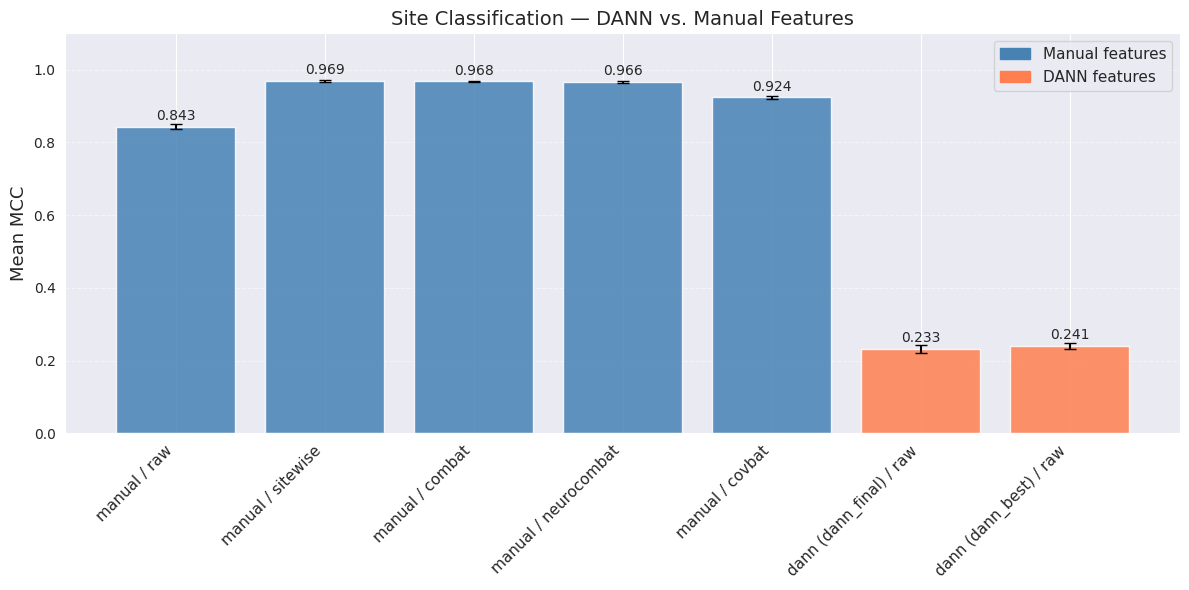

In [5]:
fig, ax = plt.subplots(figsize=(12, 6))

cs = comparison_site.copy()
labels = cs['features'] + ' / ' + cs['method']
colors = ['steelblue' if 'manual' in f else 'coral' for f in cs['features']]

bars = ax.bar(range(len(cs)), cs['MCC_mean'], yerr=cs['MCC_std'],
              capsize=4, color=colors, alpha=0.85)

for i, (bar, val) in enumerate(zip(bars, cs['MCC_mean'])):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10)

ax.set_xticks(range(len(cs)))
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=11)
ax.set_ylabel('Mean MCC', fontsize=13)
ax.set_title('Site Classification — DANN vs. Manual Features', fontsize=14)
ax.set_ylim(0, 1.1)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.axhline(y=0, color='black', linewidth=0.5)

# Legend
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='steelblue', label='Manual features'),
                    Patch(color='coral', label='DANN features')],
          fontsize=11)
fig.tight_layout()
fig.savefig(f'{FIGURES_DIR}/site_mcc_dann_vs_manual.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Pathology Classification — DANN vs. Manual Features

In [6]:
manual_cb_patho = manual_patho[manual_patho['model'] == 'catboost']
dann_patho_raw  = dann_patho[dann_patho['method'] == 'raw']

rows = []
for method in METHODS:
    mdf = manual_cb_patho[manual_cb_patho['method'] == method]
    if not mdf.empty:
        rows.append({
            'features': 'manual',
            'method': method,
            'AUC_mean': mdf['auc'].mean(),
            'AUC_std': mdf['auc'].std(),
            'MCC_mean': mdf['mcc'].mean(),
            'MCC_std': mdf['mcc'].std()
        })

for tag_val in dann_patho_raw['tag'].unique():
    tdf = dann_patho_raw[dann_patho_raw['tag'] == tag_val]
    rows.append({
        'features': f'dann ({tag_val})' if pd.notna(tag_val) else 'dann',
        'method': 'raw',
        'AUC_mean': tdf['auc'].mean(),
        'AUC_std': tdf['auc'].std(),
        'MCC_mean': tdf['mcc'].mean(),
        'MCC_std': tdf['mcc'].std()
    })

comparison_patho = pd.DataFrame(rows)
print(comparison_patho.to_string(index=False))
comparison_patho.to_csv(f'{TABLES_DIR}/patho_comparison_dann_vs_manual.csv', index=False)

         features      method  AUC_mean  AUC_std  MCC_mean  MCC_std
           manual         raw  0.799888 0.078158  0.399015 0.133543
           manual    sitewise  0.801238 0.064310  0.406709 0.115634
           manual      combat  0.807432 0.067073  0.418763 0.123067
           manual neurocombat  0.807785 0.072426  0.420239 0.121775
           manual      covbat  0.791379 0.070158  0.391753 0.127745
dann (dann_final)         raw  0.794581 0.069063  0.413514 0.128608
 dann (dann_best)         raw  0.786383 0.068753  0.401538 0.130201


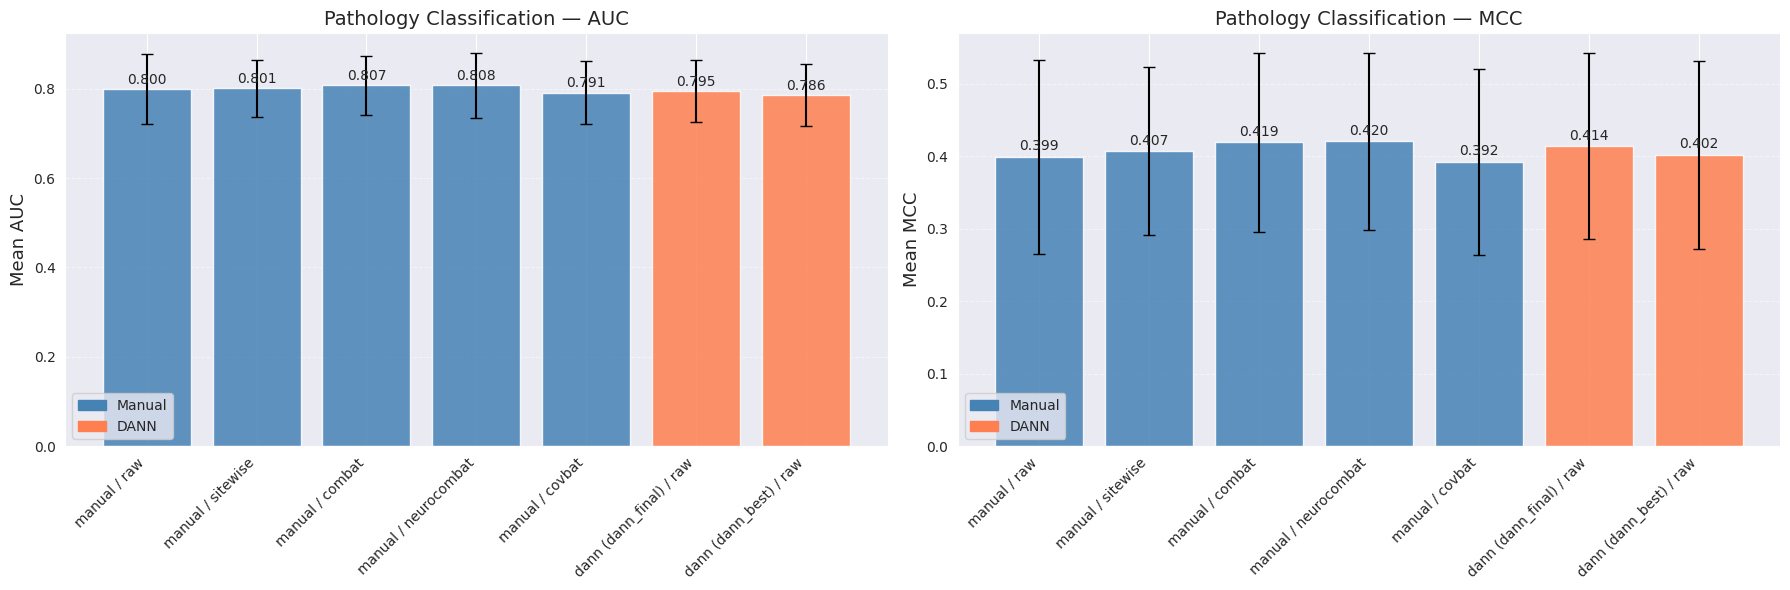

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

cp = comparison_patho.copy()
labels = cp['features'] + ' / ' + cp['method']
colors = ['steelblue' if 'manual' in f else 'coral' for f in cp['features']]

for ax, metric, metric_col in zip(axes, ['AUC', 'MCC'], ['AUC_mean', 'MCC_mean']):
    std_col = metric_col.replace('mean', 'std')
    bars = ax.bar(range(len(cp)), cp[metric_col], yerr=cp[std_col],
                  capsize=4, color=colors, alpha=0.85)

    for bar, val in zip(bars, cp[metric_col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10)

    ax.set_xticks(range(len(cp)))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=10)
    ax.set_ylabel(f'Mean {metric}', fontsize=13)
    ax.set_title(f'Pathology Classification — {metric}', fontsize=14)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(color='steelblue', label='Manual'),
                        Patch(color='coral', label='DANN')], fontsize=10)

fig.tight_layout()
fig.savefig(f'{FIGURES_DIR}/patho_dann_vs_manual.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Per-Hospital Pathology AUC — DANN vs. Manual (raw)

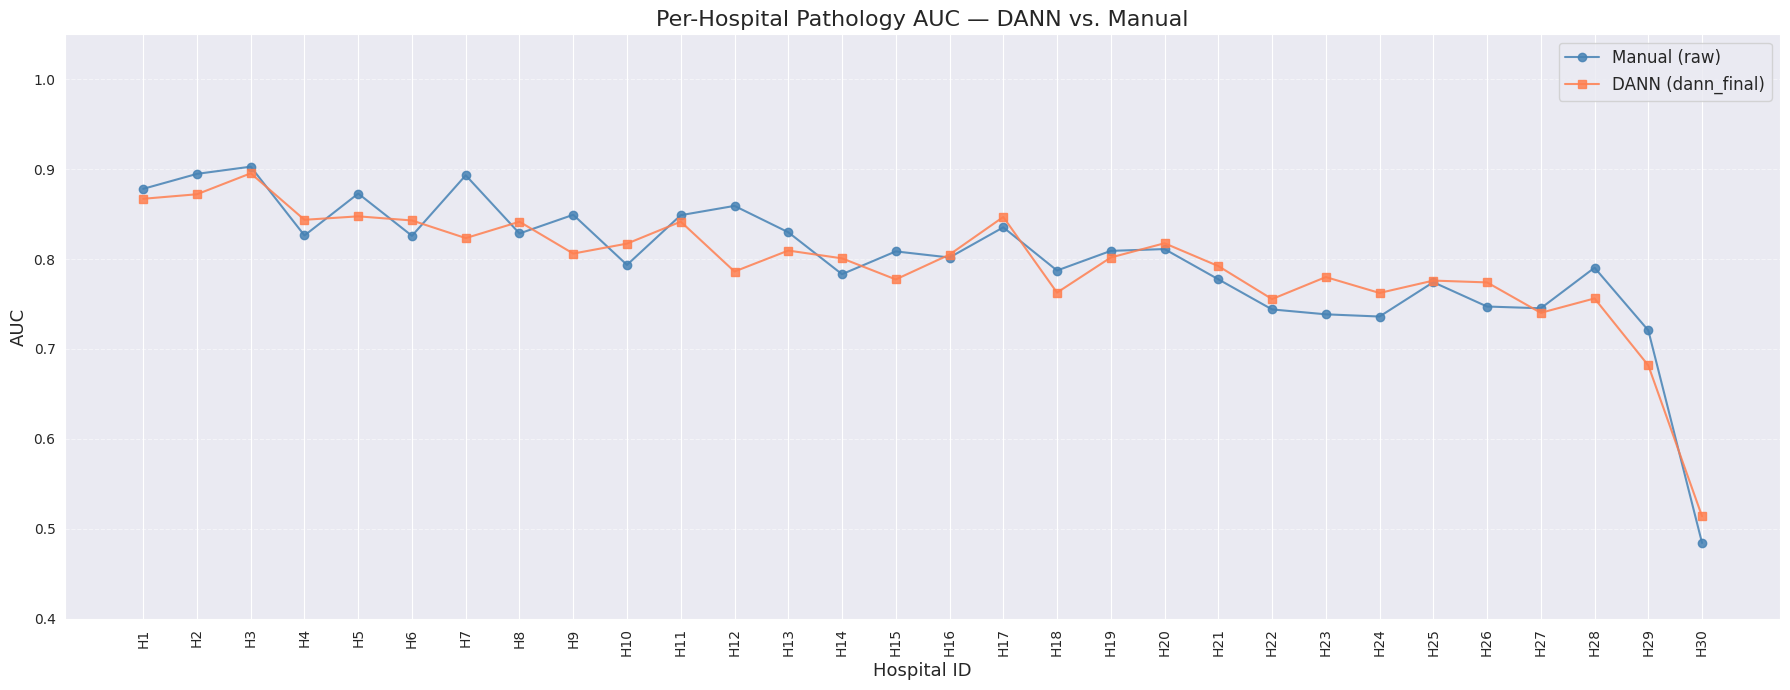

In [8]:
manual_raw_patho = manual_cb_patho[manual_cb_patho['method'] == 'raw']

# Pick the first DANN tag for per-hospital comparison
dann_tag = dann_patho_raw['tag'].iloc[0] if len(dann_patho_raw) > 0 else None
dann_sub = dann_patho_raw[dann_patho_raw['tag'] == dann_tag] if dann_tag else dann_patho_raw

# Merge on hospital
manual_hosp = manual_raw_patho.groupby('hospital')['auc'].mean()
dann_hosp   = dann_sub.groupby('hospital')['auc'].mean()

# Align to common hospitals, naturally sorted
common = manual_hosp.index.intersection(dann_hosp.index)
if len(common) == 0:
    print("No common hospitals found. Check hospital anonymization.")
    print(f"Manual hospitals: {manual_hosp.index.tolist()[:5]}...")
    print(f"DANN hospitals: {dann_hosp.index.tolist()[:5]}...")
else:
    sorted_hosp = sorted(common, key=natural_sort_key)

    fig, ax = plt.subplots(figsize=(18, 7))
    ax.plot(sorted_hosp, manual_hosp.loc[sorted_hosp], marker='o', linestyle='-',
            color='steelblue', label='Manual (raw)', alpha=0.85)
    ax.plot(sorted_hosp, dann_hosp.loc[sorted_hosp], marker='s', linestyle='-',
            color='coral', label=f'DANN ({dann_tag})', alpha=0.85)

    ax.set_title('Per-Hospital Pathology AUC — DANN vs. Manual', fontsize=16)
    ax.set_ylabel('AUC', fontsize=13)
    ax.set_xlabel('Hospital ID', fontsize=13)
    ax.tick_params(axis='x', rotation=90)
    ax.set_ylim(0.4, 1.05)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.legend(fontsize=12)
    fig.tight_layout()
    fig.savefig(f'{FIGURES_DIR}/patho_auc_per_hospital_dann_vs_manual.png', dpi=150, bbox_inches='tight')
    plt.show()

## 4. Per-Hospital Site MCC — DANN vs. Manual (raw)

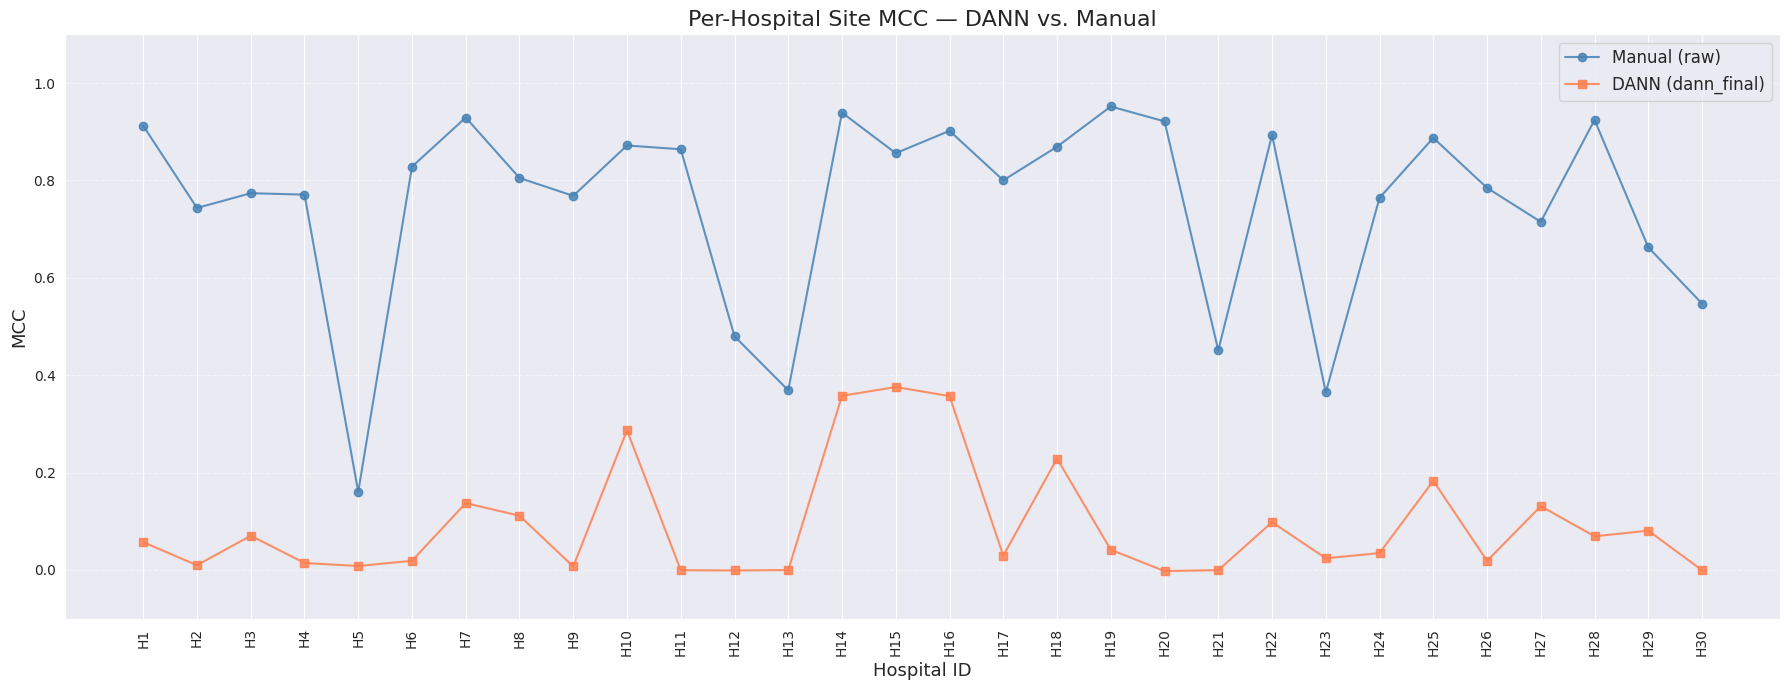

In [9]:
hospital_cols = sorted(
    [c for c in manual_raw.columns if c.startswith('mcc_H')],
    key=lambda c: natural_sort_key(c.replace('mcc_', ''))
)

if len(manual_raw) > 0 and len(dann_raw) > 0 and len(hospital_cols) > 0:
    dann_tag_site = dann_raw['tag'].iloc[0] if 'tag' in dann_raw.columns else None
    dann_sub_site = dann_raw[dann_raw['tag'] == dann_tag_site] if dann_tag_site else dann_raw

    manual_mean = manual_raw[hospital_cols].mean()
    dann_mean   = dann_sub_site[hospital_cols].mean()

    sorted_hosp = [c.replace('mcc_', '') for c in hospital_cols]

    fig, ax = plt.subplots(figsize=(18, 7))
    ax.plot(sorted_hosp, manual_mean.values, marker='o', linestyle='-',
            color='steelblue', label='Manual (raw)', alpha=0.85)
    ax.plot(sorted_hosp, dann_mean.values, marker='s', linestyle='-',
            color='coral', label=f'DANN ({dann_tag_site})', alpha=0.85)

    ax.set_title('Per-Hospital Site MCC — DANN vs. Manual', fontsize=16)
    ax.set_ylabel('MCC', fontsize=13)
    ax.set_xlabel('Hospital ID', fontsize=13)
    ax.tick_params(axis='x', rotation=90)
    ax.set_ylim(-0.1, 1.1)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.legend(fontsize=12)
    fig.tight_layout()
    fig.savefig(f'{FIGURES_DIR}/site_mcc_per_hospital_dann_vs_manual.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("Cannot create per-hospital site comparison (missing data or columns).")

## 5. Dual-Metric Summary — Site MCC vs. Pathology AUC

In [10]:
# Build a summary: for each approach, plot (site MCC, pathology AUC)
# Lower site MCC + higher patho AUC = better

rows = []

# Manual features — each harmonization method
manual_cb_site = manual_site[manual_site['model'] == 'catboost']
for method in METHODS:
    site_mcc = manual_cb_site[manual_cb_site['method'] == method]['mcc_overall'].mean()
    patho_auc = manual_cb_patho[manual_cb_patho['method'] == method]['auc'].mean()
    if not np.isnan(site_mcc) and not np.isnan(patho_auc):
        rows.append({'label': f'manual/{method}', 'site_mcc': site_mcc,
                     'patho_auc': patho_auc, 'group': 'manual'})

# DANN features
for tag_val in dann_site['tag'].unique():
    site_mcc = dann_site[dann_site['tag'] == tag_val]['mcc_overall'].mean()
    patho_sub = dann_patho[dann_patho['tag'] == tag_val] if tag_val in dann_patho['tag'].values else dann_patho
    patho_auc = patho_sub['auc'].mean()
    label = f'dann/{tag_val}' if pd.notna(tag_val) else 'dann'
    rows.append({'label': label, 'site_mcc': site_mcc,
                 'patho_auc': patho_auc, 'group': 'dann'})

dual = pd.DataFrame(rows)
print(dual.to_string(index=False))
dual.to_csv(f'{TABLES_DIR}/dual_metric_summary.csv', index=False)

             label  site_mcc  patho_auc  group
        manual/raw  0.843412   0.799888 manual
   manual/sitewise  0.968893   0.801238 manual
     manual/combat  0.967895   0.807432 manual
manual/neurocombat  0.966148   0.807785 manual
     manual/covbat  0.924323   0.791379 manual
   dann/dann_final  0.232806   0.794581   dann
    dann/dann_best  0.241068   0.786383   dann


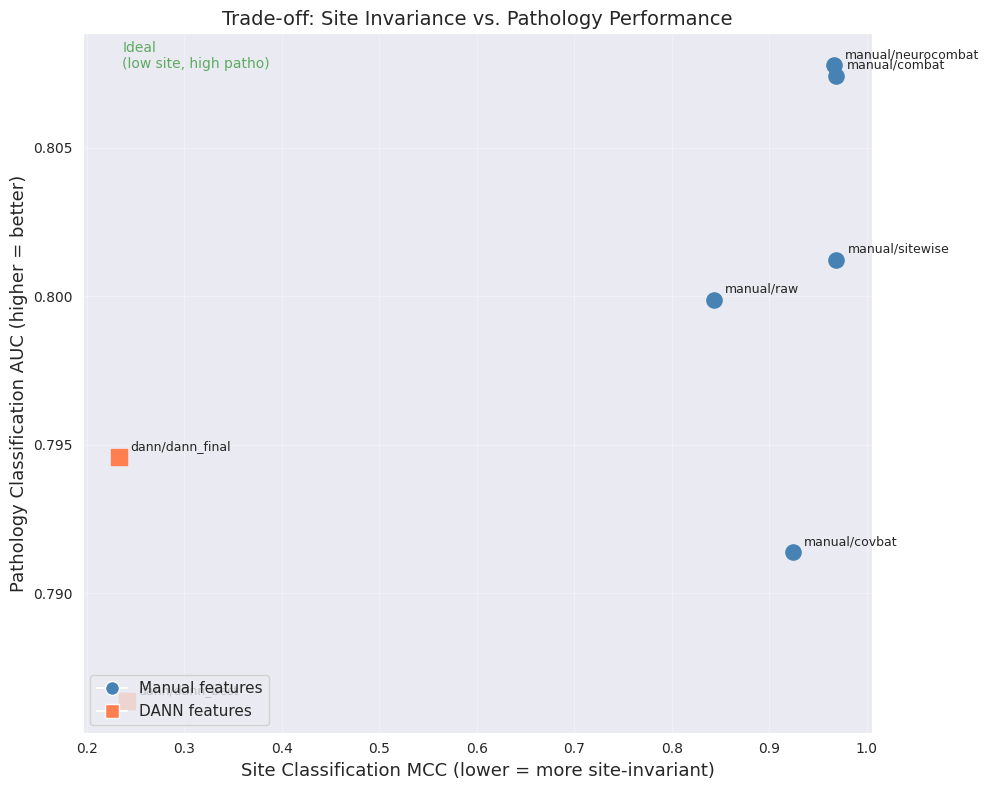

In [11]:
if len(dual) > 0:
    fig, ax = plt.subplots(figsize=(10, 8))

    for _, row in dual.iterrows():
        color = COLOR_MAP.get(row['group'], 'gray')
        marker = 'o' if row['group'] == 'manual' else 's'
        ax.scatter(row['site_mcc'], row['patho_auc'],
                   color=color, marker=marker, s=120, zorder=3)
        ax.annotate(row['label'], (row['site_mcc'], row['patho_auc']),
                    textcoords='offset points', xytext=(8, 5), fontsize=9)

    ax.set_xlabel('Site Classification MCC (lower = more site-invariant)', fontsize=13)
    ax.set_ylabel('Pathology Classification AUC (higher = better)', fontsize=13)
    ax.set_title('Trade-off: Site Invariance vs. Pathology Performance', fontsize=14)
    ax.grid(alpha=0.3)

    # Ideal corner annotation
    ax.annotate('Ideal\n(low site, high patho)', xy=(0.05, 0.95),
                fontsize=10, color='green', alpha=0.6,
                xycoords='axes fraction')

    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue',
               markersize=10, label='Manual features'),
        Line2D([0], [0], marker='s', color='w', markerfacecolor='coral',
               markersize=10, label='DANN features'),
    ]
    ax.legend(handles=legend_elements, fontsize=11, loc='lower left')

    fig.tight_layout()
    fig.savefig(f'{FIGURES_DIR}/tradeoff_site_vs_patho.png', dpi=150, bbox_inches='tight')
    plt.show()

## Conclusions

*(Fill in after running)*